## 01: Import Libraries
We import all the tools needed for 02.
- wfdb: to load the MIT-BIH dataset files
- numpy: to handle arrays and numbers
- pandas: to organize data into tables
- matplotlib: to plot signals
- collections: to count class distribution

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("All libraries imported")

All libraries imported


## 02: Load All 5 Patients from MIT-BIH Dataset
We loop through all 5 patient files and load each one.
For each patient we extract the ECG signal and the apnea
annotations from the .st file which contains sleep stage
and apnea labels for every 30-second window.

In [2]:
DATA_PATH = r"C:\Users\EmaSk\Desktop\mit-bih-data"

patients = ['slp01a', 'slp02a', 'slp03', 'slp04', 'slp14']

for p in patients:
    record = wfdb.rdrecord(f"{DATA_PATH}\\{p}")
    print(f"Patient: {p}")
    print(f"  Channels  : {record.sig_name}")
    print(f"  Samples   : {record.p_signal.shape}")
    print(f"  Duration  : {record.p_signal.shape[0]/record.fs/3600:.2f} hours")
    print()

Patient: slp01a
  Channels  : ['ECG', 'BP', 'EEG (C4-A1)', 'Resp (sum)']
  Samples   : (1800000, 4)
  Duration  : 2.00 hours

Patient: slp02a
  Channels  : ['ECG', 'BP', 'EEG (O2-A1)', 'Resp (nasal)']
  Samples   : (2700000, 4)
  Duration  : 3.00 hours

Patient: slp03
  Channels  : ['ECG', 'BP', 'EEG (C3-O1)', 'Resp (nasal)']
  Samples   : (5400000, 4)
  Duration  : 6.00 hours

Patient: slp04
  Channels  : ['ECG', 'BP', 'EEG (C3-O1)', 'Resp (nasal)']
  Samples   : (5400000, 4)
  Duration  : 6.00 hours

Patient: slp14
  Channels  : ['ECG', 'BP', 'EEG (C3-O1)', 'Resp (nasal)']
  Samples   : (5400000, 4)
  Duration  : 6.00 hours



## 03: Load ECG Signal and Apnea Labels for All Patients
For each patient we extract the ECG signal specifically.
We also read the .st annotation file which contains apnea
labels for every 30-second window of the recording.
We store everything in lists ready for segmentation.

In [5]:
all_ecg_segments = []
all_labels = []

WINDOW_SIZE = 30  # seconds

for p in patients:
    # Load record
    record = wfdb.rdrecord(f"{DATA_PATH}\\{p}")
    fs = record.fs
    ecg = record.p_signal[:, 0]  # ECG is channel 0
    
    # Load annotations from .st file
    ann = wfdb.rdann(f"{DATA_PATH}\\{p}", 'st')
    
    # Each annotation is one 30s window label
    samples_per_window = int(WINDOW_SIZE * fs)
    
    for i, sample in enumerate(ann.sample):
        # Get the label — 'A' means apnea, anything else is normal
        label_text = ann.aux_note[i].strip()
        label = 1 if 'A' in label_text else 0
        
        # Extract the ECG window
        start = sample
        end = start + samples_per_window
        
        if end <= len(ecg):
            segment = ecg[start:end]
            all_ecg_segments.append(segment)
            all_labels.append(label)

all_labels = np.array(all_labels)
total = len(all_labels)
apnea = np.sum(all_labels == 1)
normal = np.sum(all_labels == 0)

print(f"Segmentation complete")
print(f"Total windows : {total}")
print(f"Normal        : {normal} ({100*normal/total:.1f}%)")
print(f"Apnea         : {apnea} ({100*apnea/total:.1f}%)")

Segmentation complete
Total windows : 2754
Normal        : 2389 (86.7%)
Apnea         : 365 (13.3%)


## 04: Visualize Class Distribution
We plot a bar chart showing how many normal vs apnea
windows we have across all 5 patients.
This gives us a clear picture of our dataset balance.

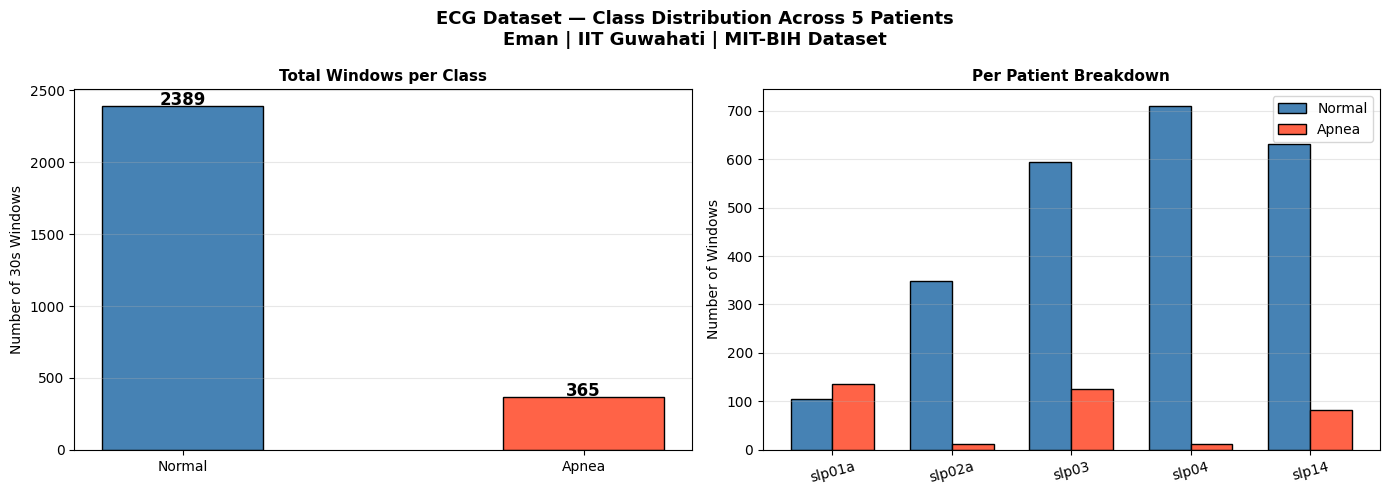

Plot saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ECG Dataset — Class Distribution Across 5 Patients\nEman | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')

# --- Plot 1: Bar chart ---
ax1 = axes[0]
labels_names = ['Normal', 'Apnea']
counts = [normal, apnea]
colors = ['steelblue', 'tomato']
bars = ax1.bar(labels_names, counts, color=colors, edgecolor='black', width=0.4)
ax1.set_title("Total Windows per Class", fontsize=11, fontweight='bold')
ax1.set_ylabel("Number of 30s Windows")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# --- Plot 2: Per patient breakdown ---
ax2 = axes[1]
patient_apnea = []
patient_normal = []

for p in patients:
    record = wfdb.rdrecord(f"{DATA_PATH}\\{p}")
    fs = record.fs
    ecg = record.p_signal[:, 0]
    ann = wfdb.rdann(f"{DATA_PATH}\\{p}", 'st')
    samples_per_window = int(WINDOW_SIZE * fs)
    
    p_apnea = 0
    p_normal = 0
    for i, sample in enumerate(ann.sample):
        label_text = ann.aux_note[i].strip()
        label = 1 if 'A' in label_text else 0
        start = sample
        end = start + samples_per_window
        if end <= len(ecg):
            if label == 1:
                p_apnea += 1
            else:
                p_normal += 1
    patient_apnea.append(p_apnea)
    patient_normal.append(p_normal)

x = np.arange(len(patients))
width = 0.35
ax2.bar(x - width/2, patient_normal, width, label='Normal', color='steelblue', edgecolor='black')
ax2.bar(x + width/2, patient_apnea, width, label='Apnea', color='tomato', edgecolor='black')
ax2.set_title("Per Patient Breakdown", fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(patients, rotation=15)
ax2.set_ylabel("Number of Windows")
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman\ecg_segmentation_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 05: Save the Segmented Dataset
We save all ECG windows and their labels to numpy files.
This means we don't need to reload and reprocess the raw
signals every time.

In [7]:
# Convert to numpy arrays
X_ecg = np.array(all_ecg_segments)
y = np.array(all_labels)

# Save to eman folder
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"

np.save(f"{SAVE_PATH}\\X_ecg.npy", X_ecg)
np.save(f"{SAVE_PATH}\\y_labels.npy", y)

print(f"Dataset saved!")
print(f"X_ecg shape : {X_ecg.shape}")
print(f"y shape     : {y.shape}")
print(f"\nX_ecg.npy  → each row is one 30s ECG window")
print(f"y_labels.npy → 0 = normal, 1 = apnea")

Dataset saved!
X_ecg shape : (2754, 7500)
y shape     : (2754,)

X_ecg.npy  → each row is one 30s ECG window
y_labels.npy → 0 = normal, 1 = apnea
